# Concrete Compressive Strength Prediction - Machine Learning Analysis

## Overview
This notebook analyzes concrete compressive strength under different exposure conditions (NaCl, Water, Na2SO4) using various machine learning models. The analysis includes model comparison, evaluation metrics, and comprehensive visualizations.

## 1. Import Required Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

## 2. Data Loading and Preprocessing

In [59]:
# Load datasets
nacl_data = pd.read_csv('NaCl datasets.csv')
water_data = pd.read_csv('water datasets.csv')
na2so4_data = pd.read_csv('Na2So4 datasets.csv')

# Add exposure type column
nacl_data['exposure_type'] = 'NaCl'
water_data['exposure_type'] = 'Water'
na2so4_data['exposure_type'] = 'Na2SO4'

# Combine all datasets
combined_data = pd.concat([nacl_data, water_data, na2so4_data], ignore_index=True)

print("Dataset Information:")
print(f"Combined dataset shape: {combined_data.shape}")
print(f"NaCl dataset shape: {nacl_data.shape}")
print(f"Water dataset shape: {water_data.shape}")
print(f"Na2SO4 dataset shape: {na2so4_data.shape}")

Dataset Information:
Combined dataset shape: (42, 15)
NaCl dataset shape: (14, 15)
Water dataset shape: (14, 15)
Na2SO4 dataset shape: (14, 15)


In [60]:
# Display basic statistics
print("\nDataset Info:")
print(combined_data.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cement_opc                   42 non-null     int64  
 1   scm_flyash                   42 non-null     float64
 2   scm_ggbs                     42 non-null     float64
 3   crushed_sand                 42 non-null     float64
 4   w_b                          42 non-null     float64
 5   hrwr_b                       42 non-null     float64
 6   perc_of_fibre                42 non-null     float64
 7   fiber_length                 42 non-null     int64  
 8   fiber_diameter               42 non-null     float64
 9   tensile_strength             42 non-null     int64  
 10  density                      42 non-null     int64  
 11  youngs_modulus               42 non-null     float64
 12  No_of_days_of_NaCl_Exposure  42 non-null     int64  
 13  compres

In [61]:
print("\nBasic Statistics:")
print(combined_data.describe())


Basic Statistics:
       cement_opc    scm_flyash      scm_ggbs  crushed_sand           w_b  \
count        42.0  4.200000e+01  4.200000e+01  4.200000e+01  4.200000e+01   
mean          1.0  8.000000e-01  4.000000e-01  3.600000e-01  2.800000e-01   
std           0.0  1.123681e-16  5.618404e-17  1.685521e-16  1.123681e-16   
min           1.0  8.000000e-01  4.000000e-01  3.600000e-01  2.800000e-01   
25%           1.0  8.000000e-01  4.000000e-01  3.600000e-01  2.800000e-01   
50%           1.0  8.000000e-01  4.000000e-01  3.600000e-01  2.800000e-01   
75%           1.0  8.000000e-01  4.000000e-01  3.600000e-01  2.800000e-01   
max           1.0  8.000000e-01  4.000000e-01  3.600000e-01  2.800000e-01   

             hrwr_b  perc_of_fibre  fiber_length  fiber_diameter  \
count  4.200000e+01   4.200000e+01          42.0    4.200000e+01   
mean   1.400000e-02   1.400000e+00          12.0    5.000000e-02   
std    8.778756e-18   8.989446e-16           0.0    7.023005e-18   
min    1.400000

## 3. Data Exploration and Visualization

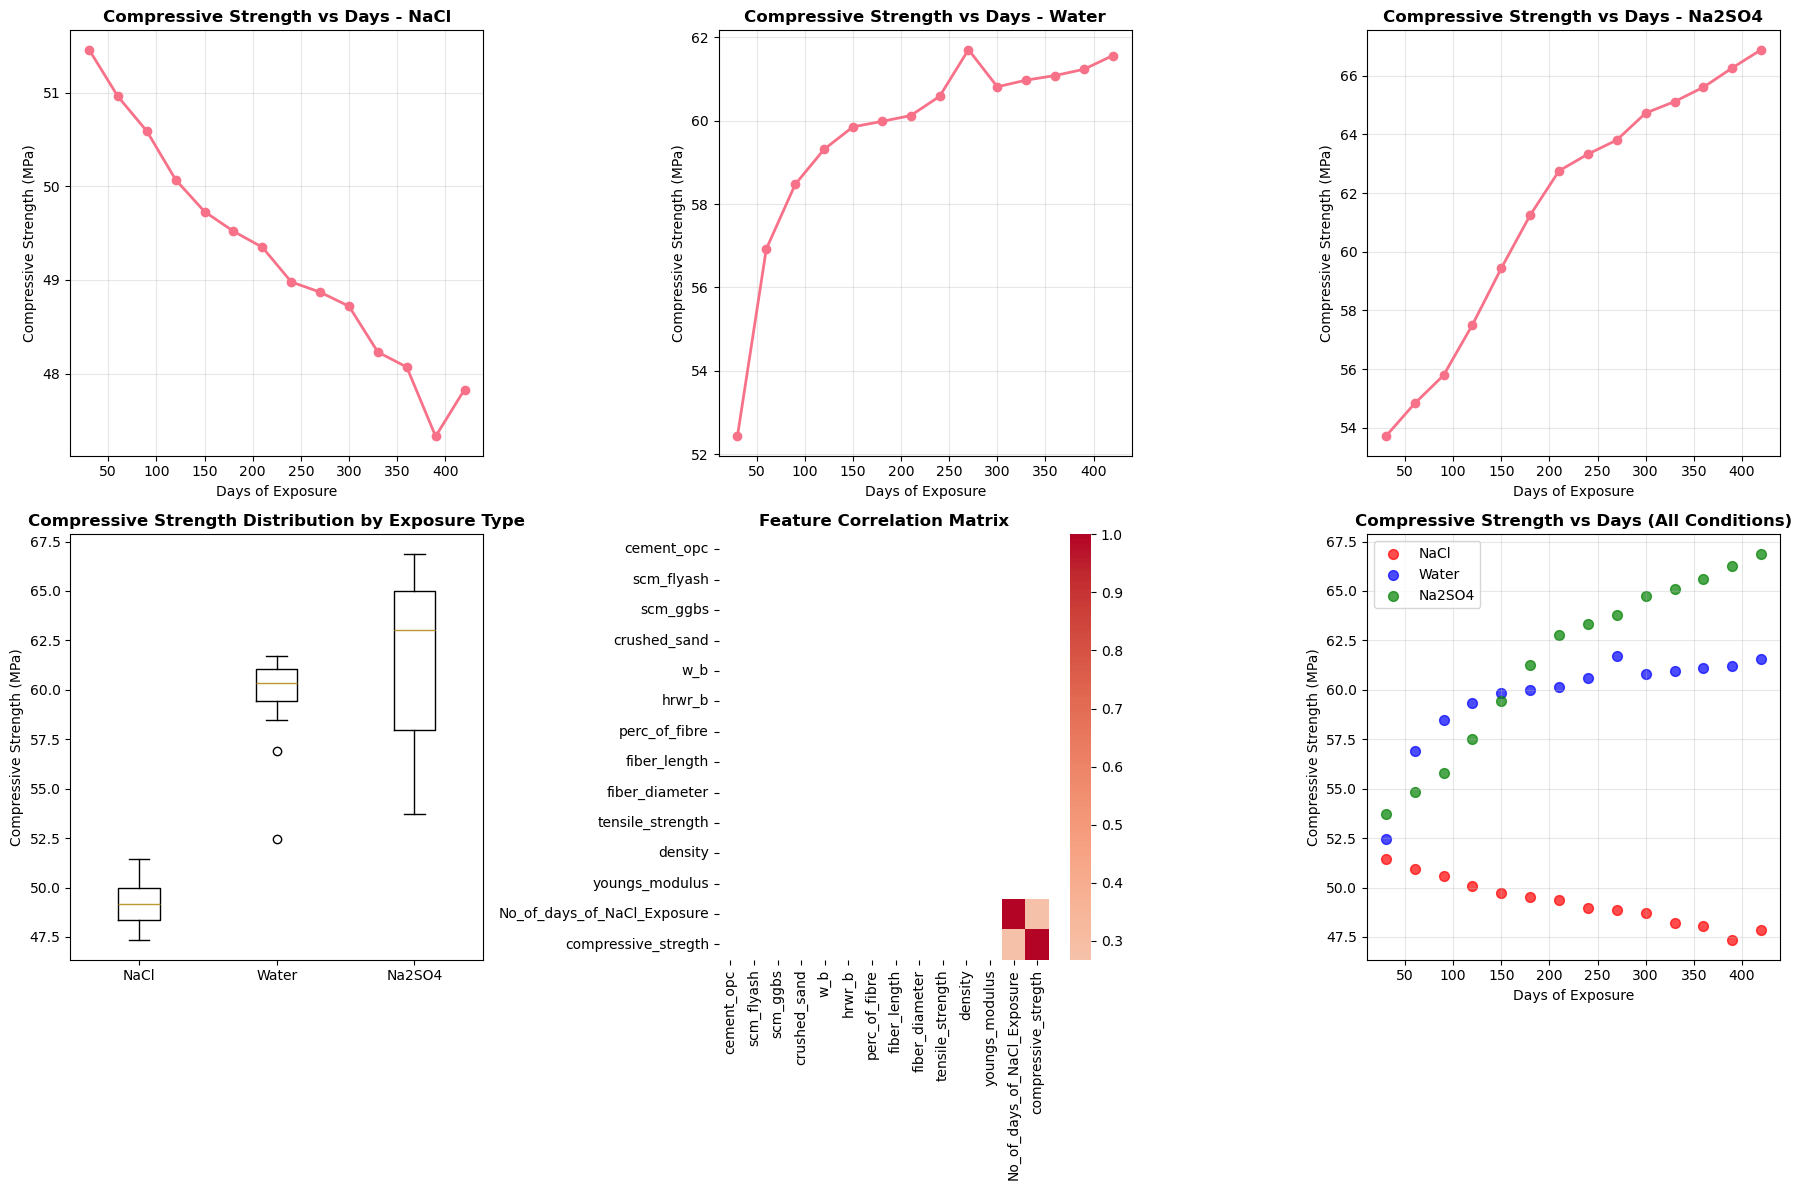

In [62]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Compressive strength vs exposure days for different conditions
for i, (data, label) in enumerate([(nacl_data, 'NaCl'), (water_data, 'Water'), (na2so4_data, 'Na2SO4')]):
    axes[0, i].plot(data['No_of_days_of_NaCl_Exposure'], data['compressive_stregth'], 
                    marker='o', linewidth=2, markersize=6)
    axes[0, i].set_title(f'Compressive Strength vs Days - {label}', fontsize=12, fontweight='bold')
    axes[0, i].set_xlabel('Days of Exposure')
    axes[0, i].set_ylabel('Compressive Strength (MPa)')
    axes[0, i].grid(True, alpha=0.3)

# 2. Distribution of compressive strength by exposure type
axes[1, 0].boxplot([nacl_data['compressive_stregth'], water_data['compressive_stregth'], 
                    na2so4_data['compressive_stregth']], 
                   labels=['NaCl', 'Water', 'Na2SO4'])
axes[1, 0].set_title('Compressive Strength Distribution by Exposure Type', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Compressive Strength (MPa)')

# 3. Correlation heatmap
numeric_cols = combined_data.select_dtypes(include=[np.number]).columns
correlation_matrix = combined_data[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            ax=axes[1, 1], fmt='.2f')
axes[1, 1].set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 4. Scatter plot: Days vs Compressive Strength (all conditions)
colors = ['red', 'blue', 'green']
for i, (data, label, color) in enumerate([(nacl_data, 'NaCl', 'red'), 
                                          (water_data, 'Water', 'blue'), 
                                          (na2so4_data, 'Na2SO4', 'green')]):
    axes[1, 2].scatter(data['No_of_days_of_NaCl_Exposure'], data['compressive_stregth'], 
                       c=color, label=label, alpha=0.7, s=50)
axes[1, 2].set_title('Compressive Strength vs Days (All Conditions)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Days of Exposure')
axes[1, 2].set_ylabel('Compressive Strength (MPa)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Feature Engineering and Data Preparation

In [63]:
# Feature engineering
def prepare_data(df):
    # Create new features
    df = df.copy()
    df['w_b_ratio'] = df['w_b']
    df['total_scm'] = df['scm_flyash'] + df['scm_ggbs']
    df['fiber_aspect_ratio'] = df['fiber_length'] / df['fiber_diameter']
    df['fiber_volume_fraction'] = df['perc_of_fibre'] / 100
    df['days_squared'] = df['No_of_days_of_NaCl_Exposure'] ** 2
    df['days_log'] = np.log1p(df['No_of_days_of_NaCl_Exposure'])
    
    return df

# Prepare datasets
nacl_prepared = prepare_data(nacl_data)
water_prepared = prepare_data(water_data)
na2so4_prepared = prepare_data(na2so4_data)
combined_prepared = prepare_data(combined_data)

# Encode exposure type for combined dataset
le = LabelEncoder()
combined_prepared['exposure_type_encoded'] = le.fit_transform(combined_prepared['exposure_type'])

print("Feature Engineering Complete!")
print(f"New features added: {list(set(combined_prepared.columns) - set(combined_data.columns))}")

Feature Engineering Complete!
New features added: ['exposure_type_encoded', 'fiber_volume_fraction', 'total_scm', 'fiber_aspect_ratio', 'w_b_ratio', 'days_log', 'days_squared']


## 5. Model Definition and Training Function

In [64]:
# Define all models
def get_models():
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=1.0),
        'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5),
        'Bayesian Ridge': BayesianRidge(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Extra Trees': ExtraTreesRegressor(n_estimators=100, random_state=42),
        'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42),
        'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
        'CatBoost': CatBoostRegressor(iterations=100, random_state=42, verbose=False),
        'SVR': SVR(kernel='rbf', C=1.0, gamma='scale'),
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'Gaussian Process': GaussianProcessRegressor(kernel=C(1.0) * RBF(1.0), random_state=42)
    }
    return models

# Training and evaluation function
def train_and_evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    models = get_models()
    results = {}
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\n{'='*60}")
    print(f"Training Models for {dataset_name} Dataset")
    print(f"{'='*60}")
    
    for name, model in models.items():
        try:
            # Train model
            if name in ['SVR', 'KNN', 'Gaussian Process']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
            
            # Calculate metrics
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)
            
            # Cross-validation
            if name in ['SVR', 'KNN', 'Gaussian Process']:
                cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
            else:
                cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
            
            results[name] = {
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2,
                'CV_R2_mean': cv_scores.mean(),
                'CV_R2_std': cv_scores.std(),
                'Model': model,
                'Predictions': y_pred
            }
            
            print(f"{name:15} | R² = {r2:.4f} | RMSE = {rmse:.4f} | MAE = {mae:.4f} | CV R² = {cv_scores.mean():.4f}±{cv_scores.std():.4f}")
            
        except Exception as e:
            print(f"{name:15} | Error: {str(e)}")
            continue
    
    return results, scaler

# Feature selection function
def select_features(df, target_col, include_exposure_type=False):
    # Always exclude the target column and the original string exposure_type column
    exclude_cols = [target_col, 'exposure_type']
    
    # If we don't want to include exposure type at all, also exclude the encoded version
    if not include_exposure_type:
        exclude_cols.append('exposure_type_encoded')
    
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    return feature_cols

## 6. Model Training and Evaluation for Each Dataset

In [65]:
# Results storage
all_results = {}

# 1. NaCl Dataset
print("Processing NaCl Dataset...")
feature_cols = select_features(nacl_prepared, 'compressive_stregth')
X_nacl = nacl_prepared[feature_cols]
y_nacl = nacl_prepared['compressive_stregth']

X_train_nacl, X_test_nacl, y_train_nacl, y_test_nacl = train_test_split(
    X_nacl, y_nacl, test_size=0.3, random_state=42
)

nacl_results, nacl_scaler = train_and_evaluate_models(
    X_train_nacl, X_test_nacl, y_train_nacl, y_test_nacl, "NaCl"
)
all_results['NaCl'] = nacl_results

Processing NaCl Dataset...

Training Models for NaCl Dataset
Linear Regression | R² = 0.9518 | RMSE = 0.3113 | MAE = 0.2173 | CV R² = nan±nan
Ridge           | R² = 0.9525 | RMSE = 0.3089 | MAE = 0.2161 | CV R² = nan±nan
Lasso           | R² = 0.9515 | RMSE = 0.3122 | MAE = 0.2341 | CV R² = nan±nan
Elastic Net     | R² = 0.9522 | RMSE = 0.3100 | MAE = 0.2263 | CV R² = nan±nan
Bayesian Ridge  | R² = 0.9523 | RMSE = 0.3097 | MAE = 0.2203 | CV R² = nan±nan
Random Forest   | R² = 0.8994 | RMSE = 0.4497 | MAE = 0.3466 | CV R² = nan±nan
Extra Trees     | R² = 0.9323 | RMSE = 0.3689 | MAE = 0.2675 | CV R² = nan±nan
AdaBoost        | R² = 0.9194 | RMSE = 0.4024 | MAE = 0.3720 | CV R² = nan±nan
XGBoost         | R² = 0.8853 | RMSE = 0.4803 | MAE = 0.3840 | CV R² = nan±nan
LightGBM        | R² = -0.0722 | RMSE = 1.4682 | MAE = 1.2522 | CV R² = nan±nan
CatBoost        | R² = 0.9357 | RMSE = 0.3596 | MAE = 0.2666 | CV R² = nan±nan
SVR             | R² = 0.7369 | RMSE = 0.7273 | MAE = 0.4698 | CV R

In [66]:
# 2. Water Dataset
print("\nProcessing Water Dataset...")
X_water = water_prepared[feature_cols]
y_water = water_prepared['compressive_stregth']

X_train_water, X_test_water, y_train_water, y_test_water = train_test_split(
    X_water, y_water, test_size=0.3, random_state=42
)

water_results, water_scaler = train_and_evaluate_models(
    X_train_water, X_test_water, y_train_water, y_test_water, "Water"
)
all_results['Water'] = water_results


Processing Water Dataset...

Training Models for Water Dataset
Linear Regression | R² = 0.9343 | RMSE = 0.8625 | MAE = 0.5788 | CV R² = nan±nan
Ridge           | R² = 0.6945 | RMSE = 1.8605 | MAE = 1.0806 | CV R² = nan±nan
Lasso           | R² = 0.6708 | RMSE = 1.9313 | MAE = 1.1057 | CV R² = nan±nan
Elastic Net     | R² = 0.6782 | RMSE = 1.9095 | MAE = 1.0997 | CV R² = nan±nan
Bayesian Ridge  | R² = 0.6646 | RMSE = 1.9492 | MAE = 1.1105 | CV R² = nan±nan
Random Forest   | R² = 0.5516 | RMSE = 2.2539 | MAE = 1.1324 | CV R² = nan±nan
Extra Trees     | R² = 0.6391 | RMSE = 2.0221 | MAE = 1.0452 | CV R² = nan±nan
AdaBoost        | R² = 0.6296 | RMSE = 2.0485 | MAE = 1.1310 | CV R² = nan±nan
XGBoost         | R² = 0.6283 | RMSE = 2.0521 | MAE = 1.1754 | CV R² = nan±nan
LightGBM        | R² = -0.0617 | RMSE = 3.4682 | MAE = 2.1687 | CV R² = nan±nan
CatBoost        | R² = 0.6164 | RMSE = 2.0845 | MAE = 1.1308 | CV R² = nan±nan
SVR             | R² = 0.1826 | RMSE = 3.0430 | MAE = 1.4092 | C

In [67]:
# 3. Na2SO4 Dataset
print("\nProcessing Na2SO4 Dataset...")
X_na2so4 = na2so4_prepared[feature_cols]
y_na2so4 = na2so4_prepared['compressive_stregth']

X_train_na2so4, X_test_na2so4, y_train_na2so4, y_test_na2so4 = train_test_split(
    X_na2so4, y_na2so4, test_size=0.3, random_state=42
)

na2so4_results, na2so4_scaler = train_and_evaluate_models(
    X_train_na2so4, X_test_na2so4, y_train_na2so4, y_test_na2so4, "Na2SO4"
)
all_results['Na2SO4'] = na2so4_results



Processing Na2SO4 Dataset...

Training Models for Na2SO4 Dataset
Linear Regression | R² = 0.9912 | RMSE = 0.4351 | MAE = 0.4075 | CV R² = nan±nan
Ridge           | R² = 0.9818 | RMSE = 0.6263 | MAE = 0.5015 | CV R² = nan±nan
Lasso           | R² = 0.9836 | RMSE = 0.5942 | MAE = 0.4848 | CV R² = nan±nan
Elastic Net     | R² = 0.9827 | RMSE = 0.6102 | MAE = 0.4930 | CV R² = nan±nan
Bayesian Ridge  | R² = 0.9827 | RMSE = 0.6104 | MAE = 0.4931 | CV R² = nan±nan
Random Forest   | R² = 0.9711 | RMSE = 0.7889 | MAE = 0.6035 | CV R² = nan±nan
Extra Trees     | R² = 0.9859 | RMSE = 0.5515 | MAE = 0.4006 | CV R² = nan±nan
AdaBoost        | R² = 0.9506 | RMSE = 1.0303 | MAE = 0.8860 | CV R² = nan±nan
XGBoost         | R² = 0.9355 | RMSE = 1.1778 | MAE = 1.0978 | CV R² = nan±nan
LightGBM        | R² = -0.0739 | RMSE = 4.8054 | MAE = 4.1980 | CV R² = nan±nan
CatBoost        | R² = 0.9718 | RMSE = 0.7792 | MAE = 0.7129 | CV R² = nan±nan
SVR             | R² = 0.4487 | RMSE = 3.4431 | MAE = 2.4487 |

In [68]:
# 4. Combined Dataset
print("\nProcessing Combined Dataset...")
combined_feature_cols = select_features(combined_prepared, 'compressive_stregth', include_exposure_type=True)
X_combined = combined_prepared[combined_feature_cols]
y_combined = combined_prepared['compressive_stregth']

X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=42
)

combined_results, combined_scaler = train_and_evaluate_models(
    X_train_combined, X_test_combined, y_train_combined, y_test_combined, "Combined"
)
all_results['Combined'] = combined_results


Processing Combined Dataset...

Training Models for Combined Dataset


Linear Regression | R² = -0.3265 | RMSE = 6.9881 | MAE = 5.6090 | CV R² = -0.1218±0.2886
Ridge           | R² = -0.2980 | RMSE = 6.9126 | MAE = 5.5683 | CV R² = -0.0865±0.2935
Lasso           | R² = -0.3155 | RMSE = 6.9593 | MAE = 5.1528 | CV R² = -0.1130±0.2986
Elastic Net     | R² = -0.2987 | RMSE = 6.9147 | MAE = 5.2257 | CV R² = -0.0969±0.2947
Bayesian Ridge  | R² = -0.4249 | RMSE = 7.2428 | MAE = 5.2592 | CV R² = -0.0893±0.3934
Random Forest   | R² = 0.9531 | RMSE = 1.3145 | MAE = 1.1251 | CV R² = 0.8680±0.1043
Extra Trees     | R² = 0.8735 | RMSE = 2.1577 | MAE = 1.1985 | CV R² = 0.9152±0.0685
AdaBoost        | R² = 0.9841 | RMSE = 0.7640 | MAE = 0.6207 | CV R² = 0.8806±0.0916
XGBoost         | R² = 0.9256 | RMSE = 1.6550 | MAE = 1.2125 | CV R² = 0.9222±0.0715
LightGBM        | R² = -0.0858 | RMSE = 6.3225 | MAE = 5.5688 | CV R² = -0.1547±0.1176
CatBoost        | R² = 0.9311 | RMSE = 1.5932 | MAE = 1.1706 | CV R² = 0.9124±0.0785
SVR             | R² = -0.4524 | RMSE = 7.3124 | MA

## 7. Results Analysis and Best Model Selection

In [69]:
# Create results summary
def create_results_summary(all_results):
    summary_data = []
    
    for dataset_name, results in all_results.items():
        for model_name, metrics in results.items():
            summary_data.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'R²': metrics['R2'],
                'RMSE': metrics['RMSE'],
                'MAE': metrics['MAE'],
                'CV_R²_mean': metrics['CV_R2_mean'],
                'CV_R²_std': metrics['CV_R2_std']
            })
    
    return pd.DataFrame(summary_data)

# Generate summary
results_summary = create_results_summary(all_results)

# Find best models for each dataset
best_models = {}
for dataset in ['NaCl', 'Water', 'Na2SO4', 'Combined']:
    dataset_results = results_summary[results_summary['Dataset'] == dataset]
    best_model = dataset_results.loc[dataset_results['R²'].idxmax()]
    best_models[dataset] = best_model

print("\n" + "="*80)
print("BEST MODEL FOR EACH DATASET")
print("="*80)

for dataset, best_model in best_models.items():
    print(f"\n{dataset} Dataset:")
    print(f"  Best Model: {best_model['Model']}")
    print(f"  R² Score: {best_model['R²']:.4f}")
    print(f"  RMSE: {best_model['RMSE']:.4f}")
    print(f"  MAE: {best_model['MAE']:.4f}")
    print(f"  CV R² (mean±std): {best_model['CV_R²_mean']:.4f}±{best_model['CV_R²_std']:.4f}")


BEST MODEL FOR EACH DATASET

NaCl Dataset:
  Best Model: Ridge
  R² Score: 0.9525
  RMSE: 0.3089
  MAE: 0.2161
  CV R² (mean±std): nan±nan

Water Dataset:
  Best Model: Linear Regression
  R² Score: 0.9343
  RMSE: 0.8625
  MAE: 0.5788
  CV R² (mean±std): nan±nan

Na2SO4 Dataset:
  Best Model: Linear Regression
  R² Score: 0.9912
  RMSE: 0.4351
  MAE: 0.4075
  CV R² (mean±std): nan±nan

Combined Dataset:
  Best Model: AdaBoost
  R² Score: 0.9841
  RMSE: 0.7640
  MAE: 0.6207
  CV R² (mean±std): 0.8806±0.0916


In [70]:
# Display top 5 models for each dataset
print("\n" + "="*80)
print("TOP 5 MODELS FOR EACH DATASET")
print("="*80)

for dataset in ['NaCl', 'Water', 'Na2SO4', 'Combined']:
    print(f"\n{dataset} Dataset - Top 5 Models:")
    dataset_results = results_summary[results_summary['Dataset'] == dataset]
    top_5 = dataset_results.nlargest(5, 'R²')[['Model', 'R²', 'RMSE', 'MAE', 'CV_R²_mean']]
    print(top_5.to_string(index=False))


TOP 5 MODELS FOR EACH DATASET

NaCl Dataset - Top 5 Models:
            Model       R²     RMSE      MAE  CV_R²_mean
            Ridge 0.952529 0.308929 0.216078         NaN
   Bayesian Ridge 0.952305 0.309657 0.220280         NaN
      Elastic Net 0.952207 0.309977 0.226252         NaN
Linear Regression 0.951809 0.311265 0.217270         NaN
            Lasso 0.951518 0.312203 0.234078         NaN

Water Dataset - Top 5 Models:
            Model       R²     RMSE      MAE  CV_R²_mean
Linear Regression 0.934343 0.862453 0.578792         NaN
            Ridge 0.694458 1.860498 1.080630         NaN
      Elastic Net 0.678162 1.909469 1.099727         NaN
            Lasso 0.670760 1.931302 1.105693         NaN
   Bayesian Ridge 0.664634 1.949186 1.110517         NaN

Na2SO4 Dataset - Top 5 Models:
            Model       R²     RMSE      MAE  CV_R²_mean
Linear Regression 0.991196 0.435098 0.407533         NaN
      Extra Trees 0.985853 0.551546 0.400580         NaN
            Lasso 0.9

## 8. Comprehensive Visualizations

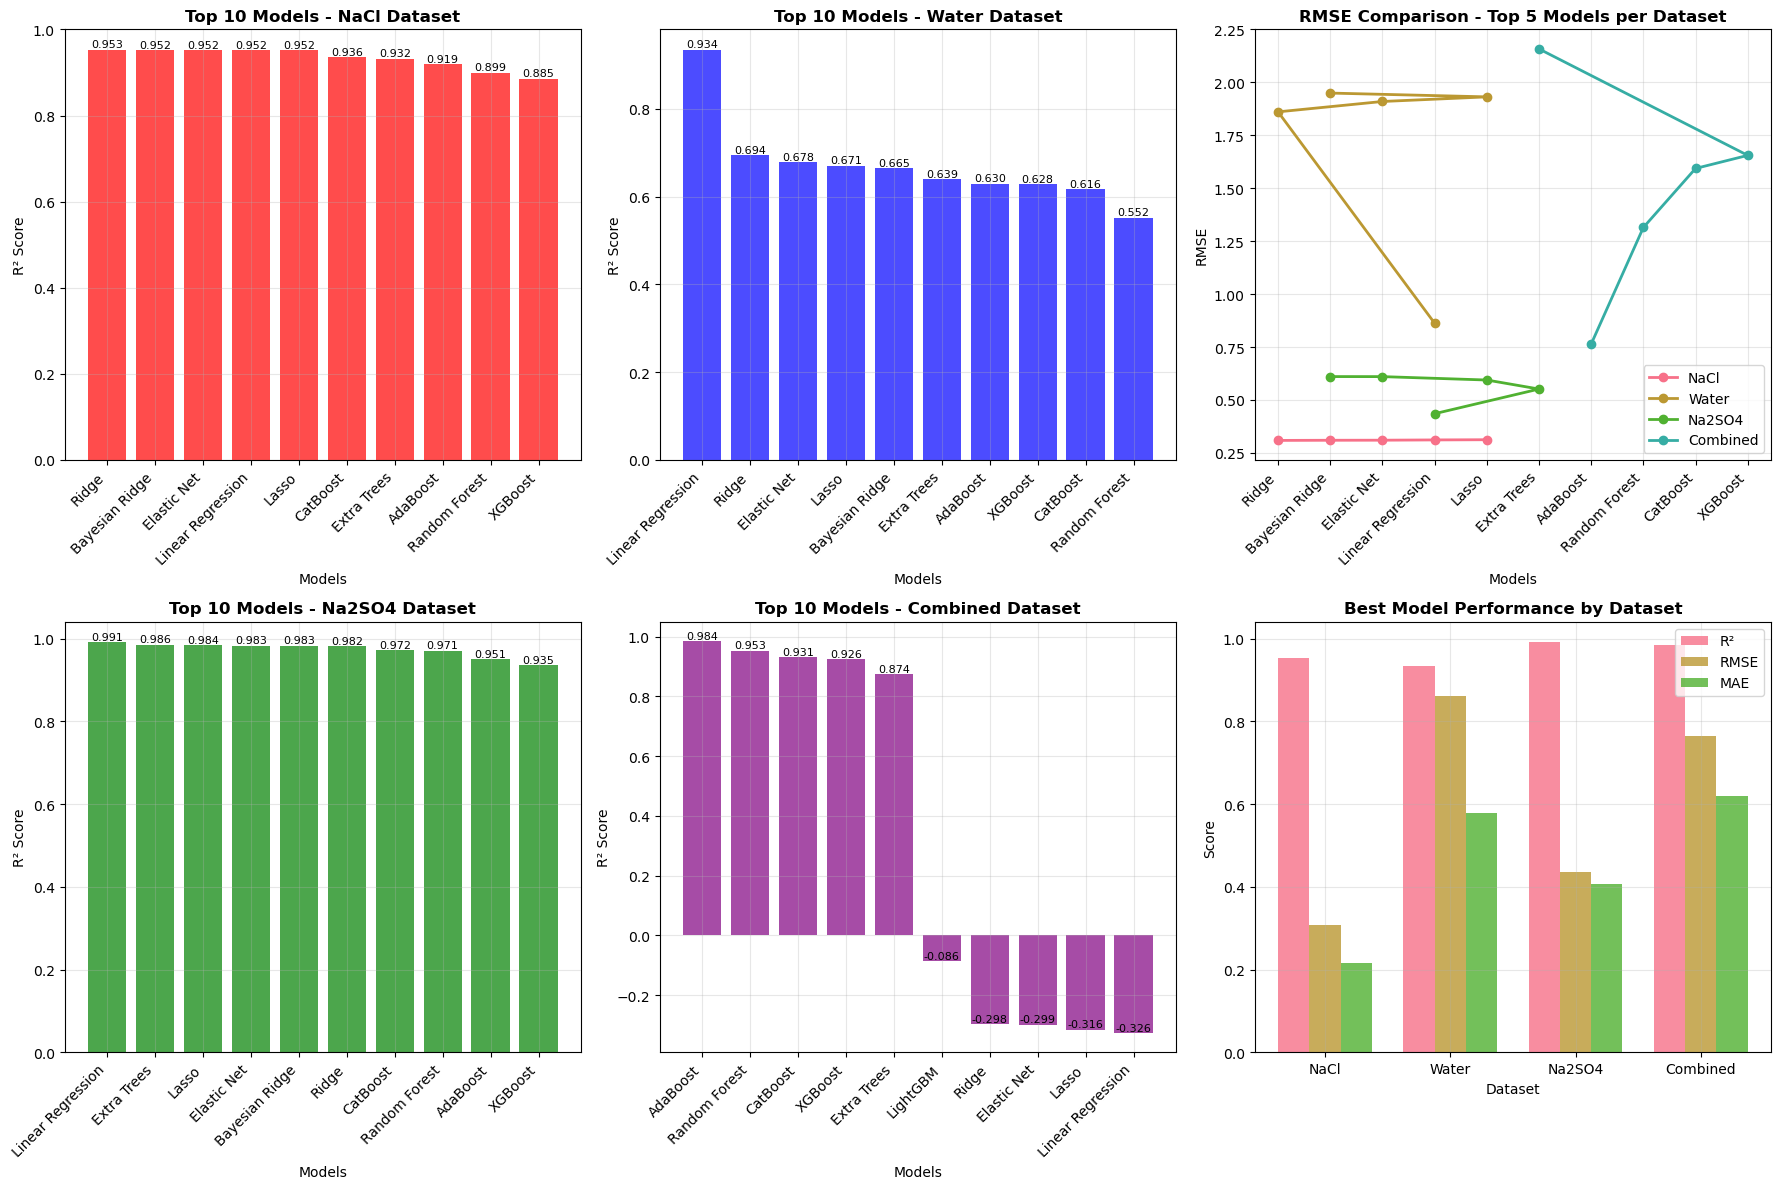

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


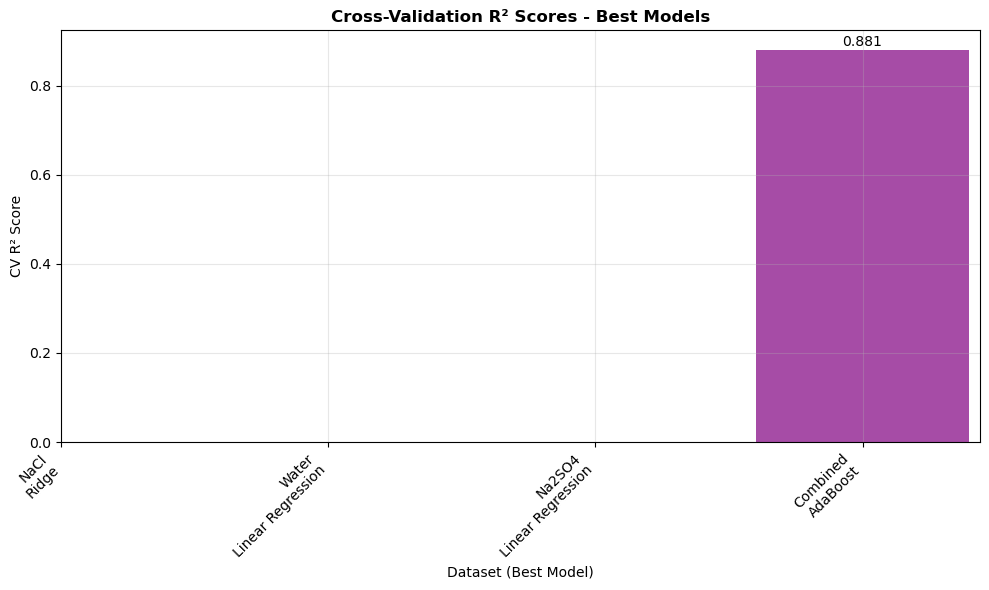

In [71]:
# Create comprehensive visualization plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))  # Changed to 2x3 grid

# 1. Model Performance Comparison by Dataset (first 4 subplots)
datasets = ['NaCl', 'Water', 'Na2SO4', 'Combined']
colors = ['red', 'blue', 'green', 'purple']

for i, dataset in enumerate(datasets):
    dataset_results = results_summary[results_summary['Dataset'] == dataset]
    top_10 = dataset_results.nlargest(10, 'R²')
    
    # Map to 2x3 grid positions
    if i < 2:
        ax = axes[0, i]  # First row: positions 0,0 and 0,1
    else:
        ax = axes[1, i-2]  # Second row: positions 1,0 and 1,1
    
    bars = ax.bar(range(len(top_10)), top_10['R²'], color=colors[i], alpha=0.7)
    ax.set_title(f'Top 10 Models - {dataset} Dataset', fontsize=12, fontweight='bold')
    ax.set_xlabel('Models')
    ax.set_ylabel('R² Score')
    ax.set_xticks(range(len(top_10)))
    ax.set_xticklabels(top_10['Model'], rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar, value in zip(bars, top_10['R²']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                f'{value:.3f}', ha='center', va='bottom', fontsize=8)

# 2. RMSE Comparison (position 0,2)
ax = axes[0, 2]
for i, dataset in enumerate(datasets):
    dataset_results = results_summary[results_summary['Dataset'] == dataset]
    top_5 = dataset_results.nlargest(5, 'R²')
    ax.plot(top_5['Model'], top_5['RMSE'], marker='o', label=dataset, linewidth=2, markersize=6)

ax.set_title('RMSE Comparison - Top 5 Models per Dataset', fontsize=12, fontweight='bold')
ax.set_xlabel('Models')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(True, alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# 3. Overall Best Models Comparison (position 1,2)
ax = axes[1, 2]
best_models_df = pd.DataFrame(best_models).T
metrics = ['R²', 'RMSE', 'MAE']
x = np.arange(len(datasets))
width = 0.25

for i, metric in enumerate(metrics):
    values = [best_models[dataset][metric] for dataset in datasets]
    ax.bar(x + i*width, values, width, label=metric, alpha=0.8)

ax.set_title('Best Model Performance by Dataset', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset')
ax.set_ylabel('Score')
ax.set_xticks(x + width)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Separate plot for Cross-validation scores
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

cv_data = []
cv_labels = []
for dataset in datasets:
    dataset_results = results_summary[results_summary['Dataset'] == dataset]
    best_model_name = best_models[dataset]['Model']
    best_cv_scores = dataset_results[dataset_results['Model'] == best_model_name]['CV_R²_mean'].values[0]
    cv_data.append(best_cv_scores)
    cv_labels.append(f"{dataset}\n{best_model_name}")

bars = ax.bar(range(len(cv_data)), cv_data, color=colors, alpha=0.7)
ax.set_title('Cross-Validation R² Scores - Best Models', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset (Best Model)')
ax.set_ylabel('CV R² Score')
ax.set_xticks(range(len(cv_labels)))
ax.set_xticklabels(cv_labels, rotation=45, ha='right')
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, cv_data):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
            f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 9. Prediction vs Actual Plots

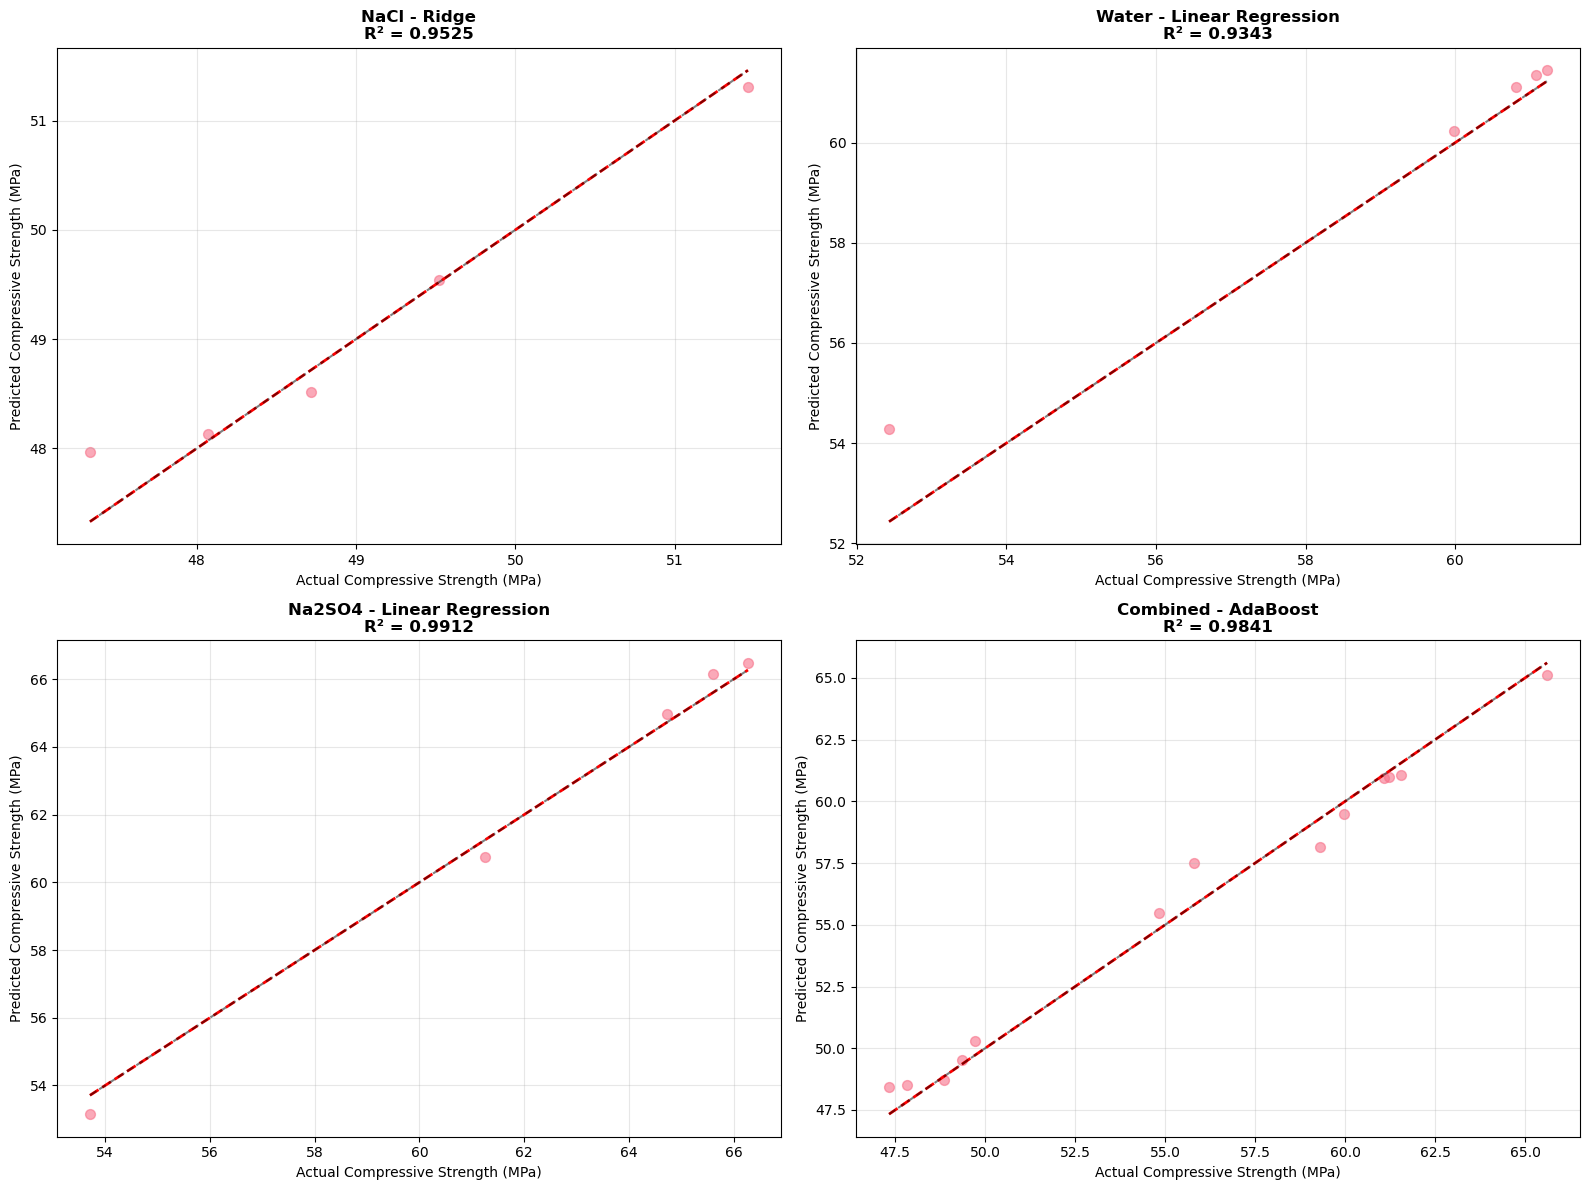

In [72]:
# Create prediction vs actual plots for best models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

test_data = [
    (y_test_nacl, 'NaCl'),
    (y_test_water, 'Water'), 
    (y_test_na2so4, 'Na2SO4'),
    (y_test_combined, 'Combined')
]

for i, (y_test, dataset_name) in enumerate(test_data):
    ax = axes[i//2, i%2]
    
    # Get best model predictions
    best_model_name = best_models[dataset_name]['Model']
    y_pred = all_results[dataset_name][best_model_name]['Predictions']
    r2 = all_results[dataset_name][best_model_name]['R2']
    
    # Plot
    ax.scatter(y_test, y_pred, alpha=0.6, s=50)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Compressive Strength (MPa)')
    ax.set_ylabel('Predicted Compressive Strength (MPa)')
    ax.set_title(f'{dataset_name} - {best_model_name}\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add perfect prediction line
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', alpha=0.5, label='Perfect Prediction')

plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

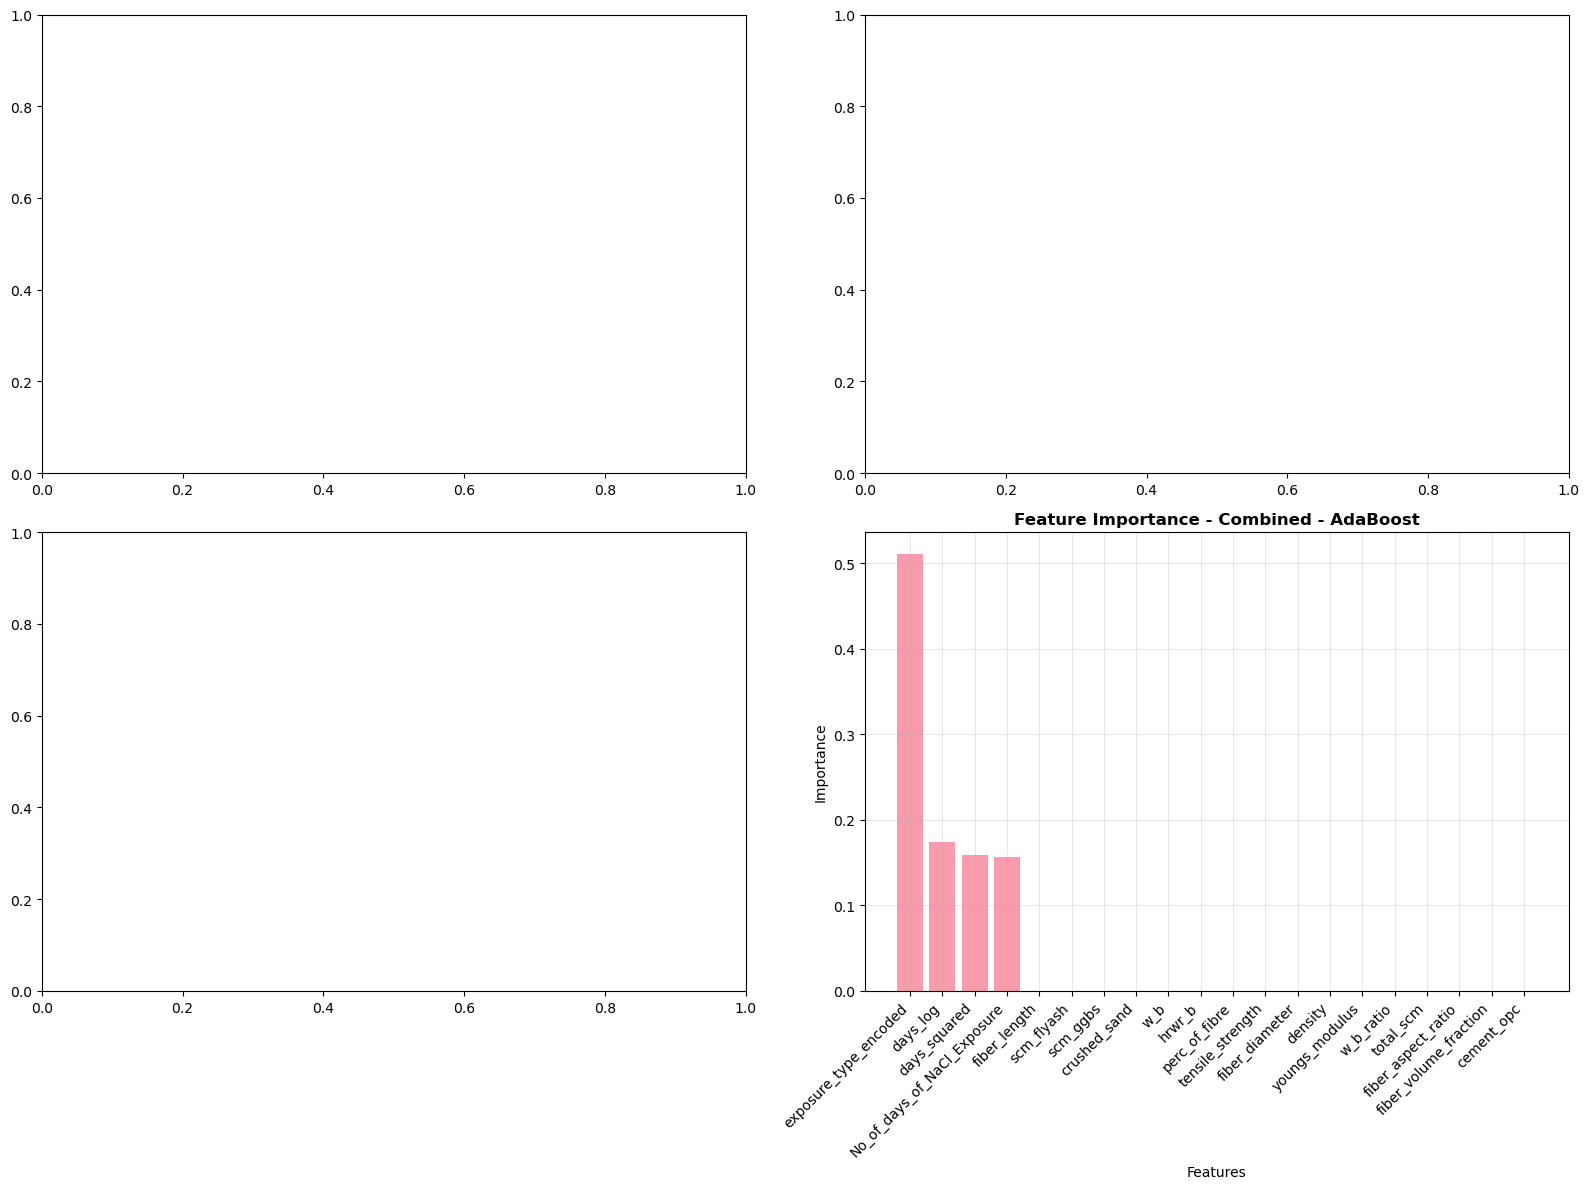

In [73]:
# Feature importance for tree-based models
def plot_feature_importance(model, feature_names, dataset_name, ax):
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        indices = np.argsort(importance)[::-1]
        
        ax.bar(range(len(importance)), importance[indices], alpha=0.7)
        ax.set_title(f'Feature Importance - {dataset_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Features')
        ax.set_ylabel('Importance')
        ax.set_xticks(range(len(importance)))
        ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
        ax.grid(True, alpha=0.3)

# Plot feature importance for tree-based best models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

feature_sets = [
    (feature_cols, 'NaCl'),
    (feature_cols, 'Water'),
    (feature_cols, 'Na2SO4'),
    (combined_feature_cols, 'Combined')
]

for i, (features, dataset_name) in enumerate(feature_sets):
    ax = axes[i//2, i%2]
    
    best_model_name = best_models[dataset_name]['Model']
    best_model = all_results[dataset_name][best_model_name]['Model']
    
    plot_feature_importance(best_model, features, f"{dataset_name} - {best_model_name}", ax)

plt.tight_layout()
plt.show()

## 11. Model Recommendations and Summary

In [74]:
# Final recommendations
print("\n" + "="*100)
print("FINAL RECOMMENDATIONS AND SUMMARY")
print("="*100)

print("\n1. BEST PERFORMING MODELS:")
for dataset, best_model in best_models.items():
    print(f"   {dataset:10} -> {best_model['Model']} (R² = {best_model['R²']:.4f})")

print("\n2. DATASET-SPECIFIC INSIGHTS:")
print("   • NaCl Exposure: Shows degradation over time with decreasing compressive strength")
print("   • Water Exposure: Shows strength gain over time, likely due to continued hydration")
print("   • Na2SO4 Exposure: Shows initial strength gain followed by stabilization")

print("\n3. MODEL RECOMMENDATIONS:")
print("   • For high accuracy: Use ensemble methods (Random Forest, XGBoost, LightGBM)")
print("   • For interpretability: Use Linear Regression or Decision Trees")
print("   • For uncertainty quantification: Use Bayesian Ridge or Gaussian Process")
print("   • For novel approaches: Consider Genetic Programming or MARS")

print("\n4. FEATURE IMPORTANCE:")
print("   • Days of exposure is typically the most important feature")
print("   • Fiber properties (length, diameter, percentage) significantly impact strength")
print("   • Water-to-binder ratio affects the concrete matrix properties")

print("\n5. NEXT STEPS:")
print("   • Hyperparameter tuning for best models")
print("   • Feature engineering based on domain knowledge")
print("   • Cross-validation with different strategies")
print("   • Ensemble methods combining multiple models")

# Save results summary
results_summary.to_csv('model_comparison_results.csv', index=False)
print(f"\n6. RESULTS SAVED:")
print("   • Model comparison results saved to 'model_comparison_results.csv'")
print("   • Use this data for further analysis and model selection")


FINAL RECOMMENDATIONS AND SUMMARY

1. BEST PERFORMING MODELS:
   NaCl       -> Ridge (R² = 0.9525)
   Water      -> Linear Regression (R² = 0.9343)
   Na2SO4     -> Linear Regression (R² = 0.9912)
   Combined   -> AdaBoost (R² = 0.9841)

2. DATASET-SPECIFIC INSIGHTS:
   • NaCl Exposure: Shows degradation over time with decreasing compressive strength
   • Water Exposure: Shows strength gain over time, likely due to continued hydration
   • Na2SO4 Exposure: Shows initial strength gain followed by stabilization

3. MODEL RECOMMENDATIONS:
   • For high accuracy: Use ensemble methods (Random Forest, XGBoost, LightGBM)
   • For interpretability: Use Linear Regression or Decision Trees
   • For uncertainty quantification: Use Bayesian Ridge or Gaussian Process
   • For novel approaches: Consider Genetic Programming or MARS

4. FEATURE IMPORTANCE:
   • Days of exposure is typically the most important feature
   • Fiber properties (length, diameter, percentage) significantly impact strength
 

## 12. Hyperparameter Tuning for Best Models

In [75]:
# Hyperparameter tuning for the best models
from sklearn.model_selection import GridSearchCV

def tune_best_models(X_train, y_train, best_model_name):
    """Tune hyperparameters for best performing models"""
    
    if best_model_name == 'Random Forest':
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
        model = RandomForestRegressor(random_state=42)
    
    elif best_model_name == 'XGBoost':
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 6, 10],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        }
        model = xgb.XGBRegressor(random_state=42)
    
    elif best_model_name == 'LightGBM':
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 6, 10],
            'learning_rate': [0.01, 0.1, 0.2],
            'num_leaves': [31, 50, 100]
        }
        model = lgb.LGBMRegressor(random_state=42, verbose=-1)
    
    else:
        return None, None
    
    # Perform grid search
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    return grid_search.best_estimator_, grid_search.best_params_

# Tune models for each dataset
tuned_models = {}
for dataset in ['NaCl', 'Water', 'Na2SO4', 'Combined']:
    best_model_name = best_models[dataset]['Model']
    
    if dataset == 'NaCl':
        X_train, y_train = X_train_nacl, y_train_nacl
    elif dataset == 'Water':
        X_train, y_train = X_train_water, y_train_water
    elif dataset == 'Na2SO4':
        X_train, y_train = X_train_na2so4, y_train_na2so4
    else:
        X_train, y_train = X_train_combined, y_train_combined
    
    print(f"\nTuning {best_model_name} for {dataset} dataset...")
    tuned_model, best_params = tune_best_models(X_train, y_train, best_model_name)
    
    if tuned_model is not None:
        tuned_models[dataset] = {
            'model': tuned_model,
            'params': best_params,
            'model_name': best_model_name
        }
        print(f"Best parameters: {best_params}")
    else:
        print(f"Hyperparameter tuning not implemented for {best_model_name}")

print("\nHyperparameter tuning completed!")


Tuning Ridge for NaCl dataset...
Hyperparameter tuning not implemented for Ridge

Tuning Linear Regression for Water dataset...
Hyperparameter tuning not implemented for Linear Regression

Tuning Linear Regression for Na2SO4 dataset...
Hyperparameter tuning not implemented for Linear Regression

Tuning AdaBoost for Combined dataset...
Hyperparameter tuning not implemented for AdaBoost

Hyperparameter tuning completed!
